# **【待测试】Ames 房价预测模型 —— 逻辑回归与评估**

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt

In [14]:
# 1. 读数据
df = pd.read_csv('./data/house-prices-advanced-regression-techniques/train.csv')
# 快速清洗
df = df[df['GrLivArea'] < 4000].copy()

In [15]:
# 2. 二分类标签
price_threshold = df['SalePrice'].quantile(0.70)
df['HighPrice'] = (df['SalePrice'] >= price_threshold).astype(int)

In [16]:
# 3. 特征列表（可自己扩展）
num_cols = ['GrLivArea', 'LotArea', 'OverallQual', 'OverallCond',
            'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
            '2ndFlrSF', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
            'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF']
cat_cols = ['Neighborhood', 'BldgType', 'HouseStyle', 'Exterior1st']

X = df[num_cols + cat_cols]
y = df['HighPrice']

In [17]:
# 4. 预处理管道
numeric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols)
    ])

In [18]:
# 5. 逻辑回归 + 超参搜索
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', log_reg)
])

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2']
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X, y)

print("Best params:", grid.best_params_)
print("CV AUC:", grid.best_score_.round(3))

Best params: {'clf__C': 1, 'clf__penalty': 'l2'}
CV AUC: 0.984


In [19]:
# 6. 测试集评估
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Hold-out Accuracy:", round(accuracy_score(y_test, y_pred),3))
print("Hold-out AUC:", round(roc_auc_score(y_test, y_prob),3))
print(classification_report(y_test, y_pred))

Hold-out Accuracy: 0.928
Hold-out AUC: 0.985
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       204
           1       0.84      0.94      0.89        88

    accuracy                           0.93       292
   macro avg       0.91      0.93      0.92       292
weighted avg       0.93      0.93      0.93       292



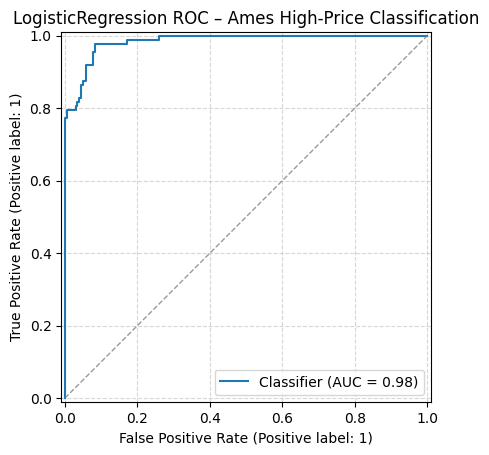

In [23]:
# 7. ROC 曲线
RocCurveDisplay.from_predictions(y_test, y_prob)
# --- 新增：网格 + 对角线 ---
ax = plt.gca()                      # 获取当前轴
ax.grid(True, linestyle='--', alpha=0.5)  # 网格
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.8)  # 对角线
# -----------------------------
plt.title("LogisticRegression ROC – Ames High-Price Classification")
plt.show()